In [1]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from datasets import load_dataset
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

In [2]:
# Load the dataset
dataset_path = "set_final.csv"
dataset = load_dataset("csv", data_files={"train": dataset_path})

# Print the first 5 rows of the dataset
dataset["train"].to_pandas().head()

,Unnamed: 0.1,Unnamed: 0,ID,Title,Summary,Content,summary_word_count,content_word_count
0,0,0,0,Rocarta,Rocarta este o enciclopedie în format electron...,Ideea de a realiza o enciclopedie multimedia d...,37,504
1,1,1,1,Muzică,Muzica este arta combinării notelor în succesi...,Instrumentele muzicale sunt utilizate în inter...,24,345
2,2,2,2,Iris (formație românească),Iris este o formație românească de muzică rock...,Istoria formației Iris se întinde pe o perioad...,244,2422
3,3,3,3,Enciclopedie,"O enciclopedie este un compendiu lexicografic,...",Scriitori din antichitate au încercat să creez...,80,110
4,4,4,4,Wikipedia,"Wikipedia este o enciclopedie generală, dispo...",Wikipedia a fost descrisă ca o Enciclopedie Ga...,219,940


In [3]:
# Print the number of rows in the dataset
len(dataset["train"])

72141

In [4]:
df = dataset["train"].to_pandas()

# Compute the mean of the content word count
mean_content_length = df["content_word_count"].mean()
print(f"The average article length (word count): {mean_content_length:.2f}")

The average article length (word count): 774.44


In [5]:
# Define intervals for content word count (0 to 2000 with steps of 100)
ranges = list(range(0, 2100, 100))

df["interval"] = pd.cut(df["content_word_count"], bins=ranges, right=False)

# Count the number of articles in each interval 
article_counts_per_range = df.groupby("interval")["content_word_count"].count()

print(article_counts_per_range)

interval
[0, 100)         4941
[100, 200)      13280
[200, 300)      10619
[300, 400)       8149
[400, 500)       5986
[500, 600)       4647
[600, 700)       3625
[700, 800)       2801
[800, 900)       2319
[900, 1000)      1779
[1000, 1100)     1569
[1100, 1200)     1299
[1200, 1300)     1077
[1300, 1400)      891
[1400, 1500)      818
[1500, 1600)      737
[1600, 1700)      596
[1700, 1800)      530
[1800, 1900)      475
[1900, 2000)      405
Name: content_word_count, dtype: int64


C:\Users\Mihai\AppData\Local\Temp\ipykernel_7620\3894269472.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  article_counts_per_range = df.groupby("interval")["content_word_count"].count()


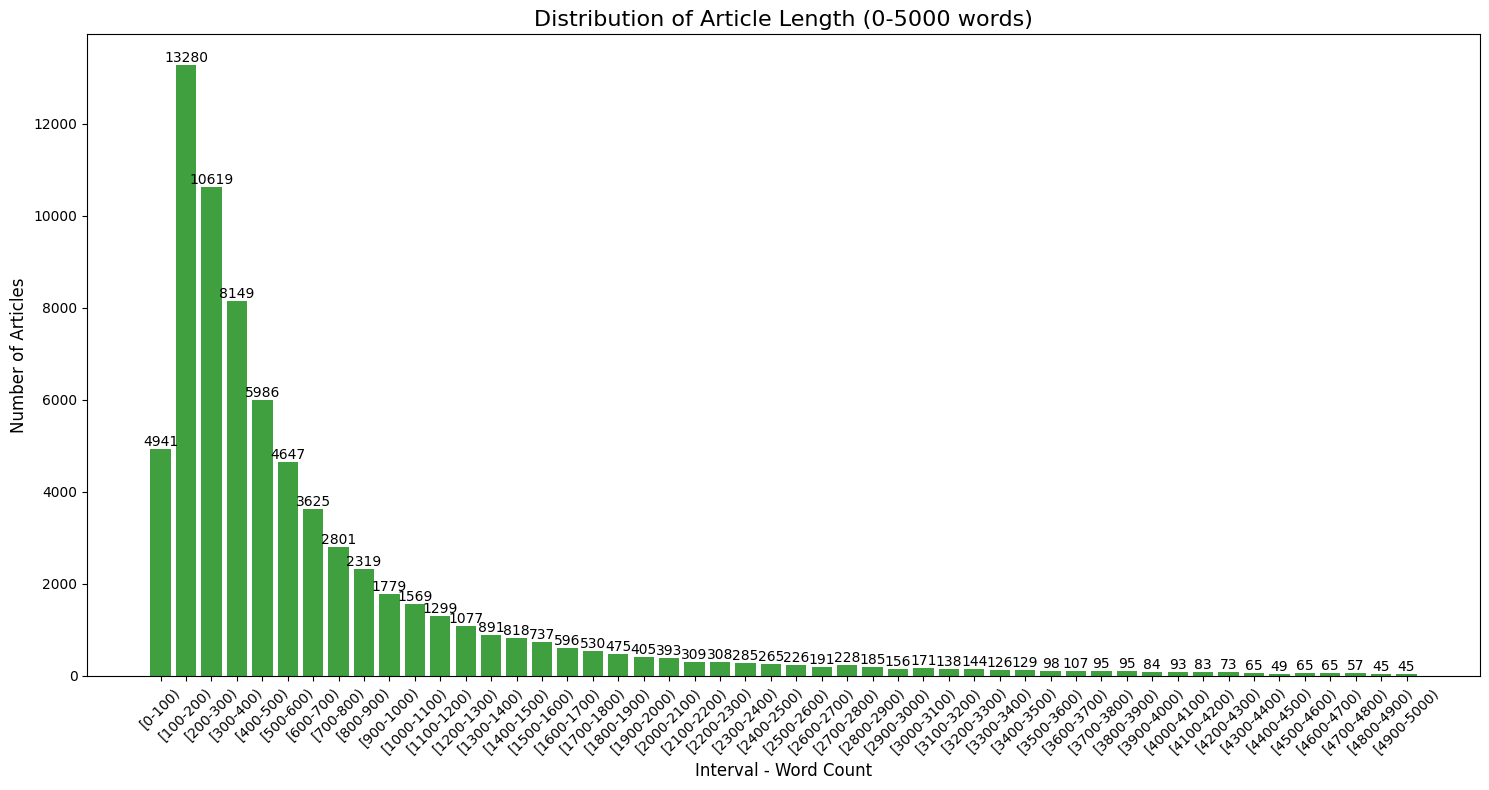

In [6]:
# Define new intervals for histogram (0 to 5000 with steps of 100)
intervals = list(range(0, 5100, 100))

histogram_data = pd.cut(df["content_word_count"], bins=intervals, right=False)

# Count the number of articles in each category (histogram bins)
counts = histogram_data.value_counts().sort_index()  # Sort counts by category

plt.figure(figsize=(15, 8)) 
bars = plt.bar(range(len(counts)), counts.values, alpha=0.75, color='green')

for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             str(int(counts.values[i])), ha='center', va='bottom')

# Set labels for the x-axis
x_axis_labels = [f'[{intervals[i]}-{intervals[i+1]})' for i in range(len(intervals)-1)]
plt.xticks(range(len(counts)), x_axis_labels, rotation=45)  

# Set title, x-axis label, and y-axis label for the plot
plt.title("Distribution of Article Length (0-5000 words)", fontsize=16)
plt.xlabel("Interval - Word Count", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the histogram plot
plt.savefig("before.png")
plt.show()

In [7]:
# Filter data (keep articles with word count between 100 and 2000)
filtered_df = df[(df["content_word_count"] >= 100) & (df["content_word_count"] <= 2000)]

# Save the filtered data to a new CSV file
filtered_df.to_csv("final_filtered_set.csv", index=False)

# Print some statistics to confirm filtering results
print(f"Total number of articles before filtering: {len(df)}")
print(f"Number of articles after filtering: {len(filtered_df)}")
print(f"Articles removed: {len(df) - len(filtered_df)}")
print(f"\nNew average article length: {filtered_df['content_word_count'].mean():.2f}")
print(f"Minimum length: {filtered_df['content_word_count'].min()}")
print(f"Maximum length: {filtered_df['content_word_count'].max()}")

Total number of articles before filtering: 72141
Number of articles after filtering: 61604
Articles removed: 10537

New average article length: 524.67
Minimum length: 100
Maximum length: 2000


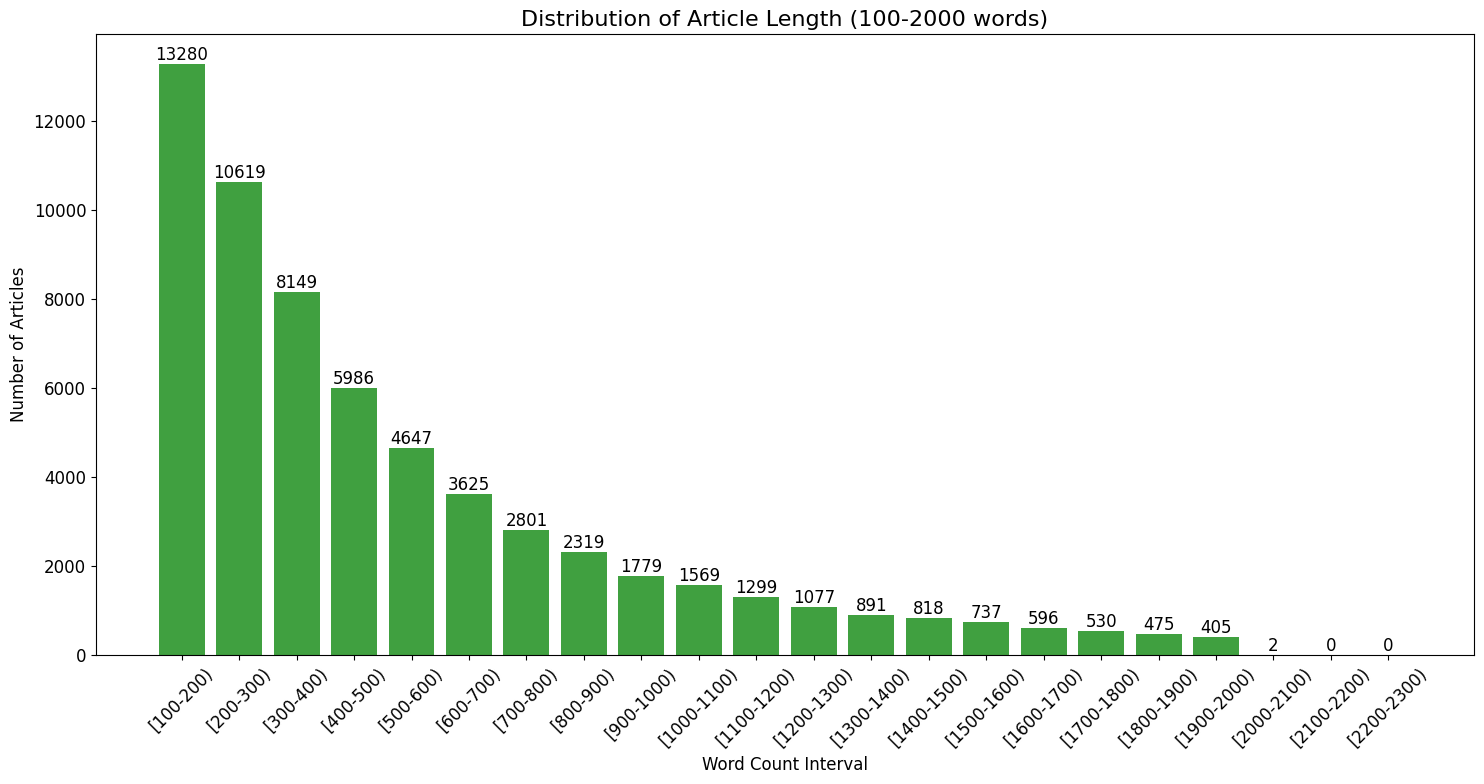

In [9]:
plt.figure(figsize=(15, 8)) 
plt.rcParams['font.size'] = 12  

# Create intervals from 100 to 2000 with a step of 100
intervals = list(range(100, 2400, 100))

hist_data = pd.cut(filtered_df["content_word_count"], bins=intervals, right=False)
counts = hist_data.value_counts().sort_index()
bars = plt.bar(range(len(counts)), counts.values, alpha=0.75, color='green')

# Add the number of articles above each bar
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             str(int(counts.values[i])),
             ha='center', va='bottom')

# Set the x-axis labels (interval ranges)
plt.xticks(range(len(counts)), 
          [f'[{intervals[i]}-{intervals[i+1]})' for i in range(len(intervals)-1)],
          rotation=45) 

# Set the title and axis labels
plt.title("Distribution of Article Length (100-2000 words)", fontsize=16)
plt.xlabel("Word Count Interval", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)

plt.tight_layout() # Adjust layout to prevent overlapping elements
plt.savefig("after.png")
plt.show() # Display the plot

In [9]:
# Compute the mean of the content word count
mean_content_length = filtered_df["content_word_count"].mean()
print(f"The average article length (word count): {mean_content_length:.2f}")

The average article length (word count): 524.67
